# The Ski-Jump: Click Distribution by Position

Click share drops from position 1 to ~8, then upticks at the boundary. Every search engine sees this. It's attributed to "position bias" — a label, not an explanation.

This notebook decomposes the ski-jump using AdSERP eye-tracking data:
1. **Click position distribution** — replicate the ski-jump shape
2. **Satisficers vs optimizers** — who drives the boundary uptick?
3. **LHIPA (cognitive load)** — are boundary clickers working harder?
4. **SERP difficulty** — does relevance spread modulate the shape?
5. **Fixation investment** — how does evaluation effort vary by click position?

**Key context:** AdSERP is a forced-choice task — participants must click a result. There is no "next page" or abandonment. Position 10 IS the boundary, replacing the pagination boundary in production search.

In [1]:
from data_loader import *
setup_plotting()

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter, defaultdict

## 1. Click position distribution

In [2]:
trial_ids = get_trial_ids()

click_data = []
for tid in trial_ids:
    doc_h, scr_h, ts = get_trial_meta(tid)
    if not doc_h: continue
    n_res = count_results_html(tid)
    if n_res < 3: continue
    
    events, scrolls, clicks = load_mouse_events(tid)
    if not clicks: continue
    
    click_t, click_x, click_y = clicks[0]
    scroll_ts = [s[0] for s in scrolls]
    scroll_ys = [s[1] for s in scrolls]
    scroll_y = interpolate_scroll(click_t, scroll_ts, scroll_ys)
    
    tops = result_band_tops(n_res, doc_h)
    pos = assign_fixation_to_position(click_y, scroll_y, tops, n_res)
    if pos < 0: pos = 0
    
    parts = tid.split('-')
    click_data.append({
        'tid': tid,
        'participant': parts[0],
        'batch': int(parts[1].replace('b', '')),
        'trial': int(parts[2].replace('t', '')),
        'click_pos': pos,
        'n_results': n_res,
    })

print(f'Trials with clicks: {len(click_data)}')

# Click share by position
counts = Counter(d['click_pos'] for d in click_data)
total = len(click_data)
max_pos = 11

positions = list(range(max_pos))
shares = [counts.get(p, 0) / total * 100 for p in positions]

print(f'\n{"Pos":>4s}  {"Clicks":>7s}  {"Share":>7s}')
print('-' * 25)
for p in positions:
    print(f'{p:4d}  {counts.get(p,0):7d}  {shares[p]:6.1f}%')

# The ski-jump check
if counts.get(10, 0) > counts.get(9, 0):
    print(f'\nSki-jump confirmed: position 10 ({shares[10]:.1f}%) > position 9 ({shares[9]:.1f}%)')

Trials with clicks: 2772

 Pos   Clicks    Share
-------------------------
   0      492    17.7%
   1      373    13.5%
   2      394    14.2%
   3      371    13.4%
   4      264     9.5%
   5      183     6.6%
   6      158     5.7%
   7      106     3.8%
   8      104     3.8%
   9       81     2.9%
  10       91     3.3%

Ski-jump confirmed: position 10 (3.3%) > position 9 (2.9%)


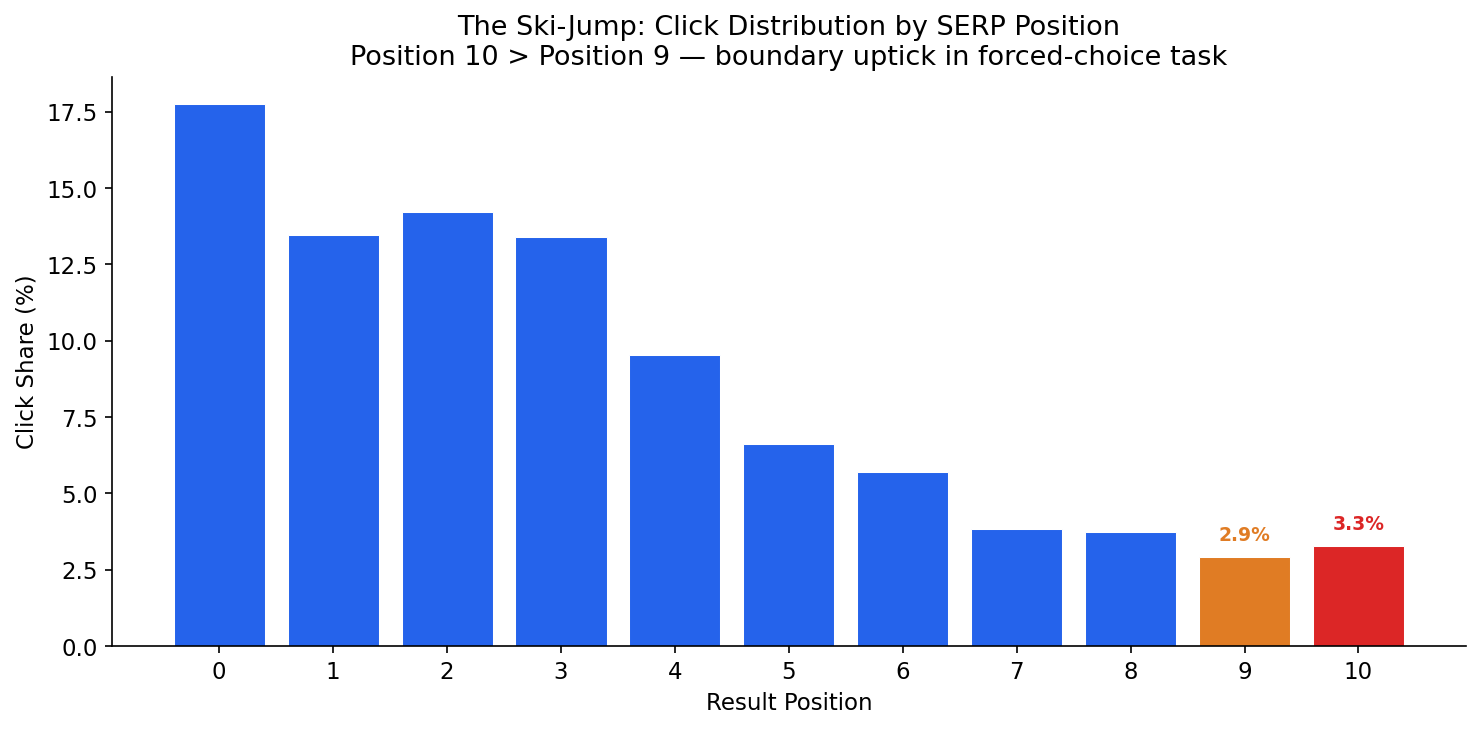

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2563eb'] * max_pos
# Highlight the uptick
if shares[10] > shares[9]:
    colors[10] = '#dc2626'
    colors[9] = '#e07c24'

bars = ax.bar(positions, shares, color=colors, edgecolor='white', linewidth=0.5)

# Annotate the ski-jump
ax.annotate(f'{shares[9]:.1f}%', (9, shares[9]), textcoords='offset points',
            xytext=(0, 8), ha='center', fontsize=9, color='#e07c24', fontweight='bold')
ax.annotate(f'{shares[10]:.1f}%', (10, shares[10]), textcoords='offset points',
            xytext=(0, 8), ha='center', fontsize=9, color='#dc2626', fontweight='bold')

ax.set_xlabel('Result Position')
ax.set_ylabel('Click Share (%)')
ax.set_title('The Ski-Jump: Click Distribution by SERP Position\n'
             'Position 10 > Position 9 — boundary uptick in forced-choice task')
ax.set_xticks(positions)

plt.tight_layout()
plt.savefig('plot_skijump_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. Satisficers vs Optimizers

Split participants by median regression rate. Do optimizers (high regression rate) drive the boundary uptick? They scan more thoroughly — if they click at position 9+, it's because they evaluated the whole SERP.

In [4]:
catalog = load_catalog_indexed()

# Per-participant regression rate
participant_regressions = defaultdict(list)
for tid, meta in catalog.items():
    participant_regressions[meta['participant']].append(meta['has_scroll_regression'])

participant_reg_rate = {pid: np.mean(regs) for pid, regs in participant_regressions.items()}
median_reg = np.median(list(participant_reg_rate.values()))

satisficers = {pid for pid, rate in participant_reg_rate.items() if rate <= median_reg}
optimizers = {pid for pid, rate in participant_reg_rate.items() if rate > median_reg}

sat_clicks = [d['click_pos'] for d in click_data if d['participant'] in satisficers]
opt_clicks = [d['click_pos'] for d in click_data if d['participant'] in optimizers]

sat_counts = Counter(sat_clicks)
opt_counts = Counter(opt_clicks)
sat_total, opt_total = len(sat_clicks), len(opt_clicks)

print(f'Median regression rate: {median_reg:.2f}')
print(f'Satisficers: {len(satisficers)} participants, {sat_total} trials')
print(f'Optimizers:  {len(optimizers)} participants, {opt_total} trials')

# Boundary click rates
sat_boundary = sum(1 for c in sat_clicks if c >= 9) / sat_total * 100
opt_boundary = sum(1 for c in opt_clicks if c >= 9) / opt_total * 100
print(f'\nBoundary clicks (pos 9+):')
print(f'  Satisficers: {sat_boundary:.1f}%')
print(f'  Optimizers:  {opt_boundary:.1f}%')
print(f'  Ratio: {opt_boundary/sat_boundary:.2f}x')

Median regression rate: 0.66
Satisficers: 24 participants, 1416 trials
Optimizers:  23 participants, 1356 trials

Boundary clicks (pos 9+):
  Satisficers: 9.3%
  Optimizers:  14.5%
  Ratio: 1.56x


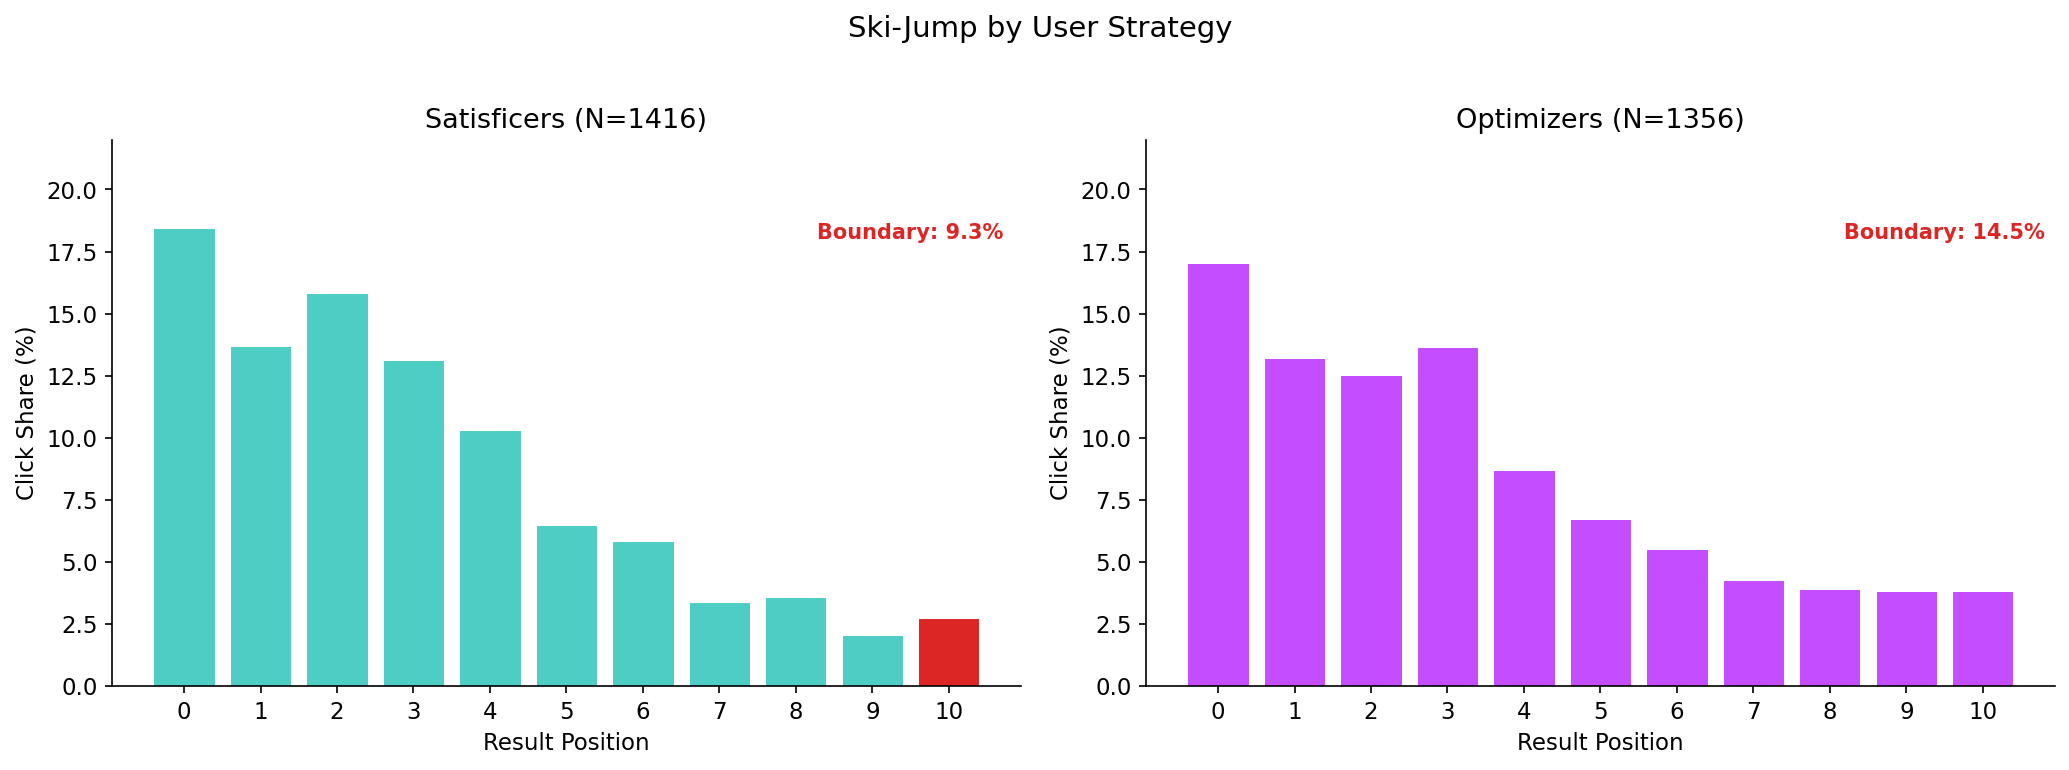

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Side-by-side distributions
for ax, clicks, label, color, n_total in [
    (axes[0], sat_clicks, f'Satisficers (N={sat_total})', '#4ecdc4', sat_total),
    (axes[1], opt_clicks, f'Optimizers (N={opt_total})', '#c44dff', opt_total),
]:
    cnts = Counter(clicks)
    sh = [cnts.get(p, 0) / n_total * 100 for p in positions]
    cols = [color] * max_pos
    if sh[10] > sh[9]:
        cols[10] = '#dc2626'
    ax.bar(positions, sh, color=cols, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Result Position')
    ax.set_ylabel('Click Share (%)')
    ax.set_title(label)
    ax.set_xticks(positions)
    ax.set_ylim(0, 22)
    # Annotate boundary
    bnd = sum(1 for c in clicks if c >= 9) / n_total * 100
    ax.annotate(f'Boundary: {bnd:.1f}%', (9.5, 18), ha='center',
                fontsize=10, fontweight='bold', color='#dc2626')

plt.suptitle('Ski-Jump by User Strategy', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_skijump_strategy.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. LHIPA by click position

LHIPA (Low/High Index of Pupillary Activity, Duchowski et al. 2020) measures cognitive load from pupil diameter. Lower LHIPA = higher cognitive load. Does cognitive load differ for boundary clickers?

In [6]:
lhipa = load_lhipa()

lhipa_by_pos = defaultdict(list)
for d in click_data:
    tid = d['tid']
    if tid in lhipa and lhipa[tid].get('lhipa') is not None:
        lhipa_by_pos[d['click_pos']].append(lhipa[tid]['lhipa'])

print(f'{"Pos":>4s}  {"LHIPA":>8s}  {"N":>5s}')
print('-' * 22)
lhipa_means = []
lhipa_sems = []
lhipa_ns = []
for p in positions:
    vals = lhipa_by_pos.get(p, [])
    m = np.mean(vals) if vals else np.nan
    se = np.std(vals) / len(vals)**0.5 if len(vals) > 1 else 0
    lhipa_means.append(m)
    lhipa_sems.append(se)
    lhipa_ns.append(len(vals))
    print(f'{p:4d}  {m:8.4f}  {len(vals):5d}')

# Test: positions 0-8 vs positions 9-10
early_lhipa = [v for p in range(9) for v in lhipa_by_pos.get(p, [])]
boundary_lhipa = [v for p in [9, 10] for v in lhipa_by_pos.get(p, [])]
u, p_val = stats.mannwhitneyu(early_lhipa, boundary_lhipa)
print(f'\nPositions 0-8 vs 9-10:')
print(f'  Early: mean={np.mean(early_lhipa):.4f} (N={len(early_lhipa)})')
print(f'  Boundary: mean={np.mean(boundary_lhipa):.4f} (N={len(boundary_lhipa)})')
print(f'  Mann-Whitney: p={p_val:.4f}')
print(f'  Direction: boundary LHIPA is {"lower" if np.mean(boundary_lhipa) < np.mean(early_lhipa) else "higher"} = {"higher" if np.mean(boundary_lhipa) < np.mean(early_lhipa) else "lower"} cognitive load')

 Pos     LHIPA      N
----------------------
   0    0.0484    470
   1    0.0497    365
   2    0.0510    388
   3    0.0499    366
   4    0.0487    263
   5    0.0483    181
   6    0.0471    158
   7    0.0480    106
   8    0.0498    103
   9    0.0409     79
  10    0.0419     88

Positions 0-8 vs 9-10:
  Early: mean=0.0492 (N=2400)
  Boundary: mean=0.0414 (N=167)
  Mann-Whitney: p=0.0000
  Direction: boundary LHIPA is lower = higher cognitive load


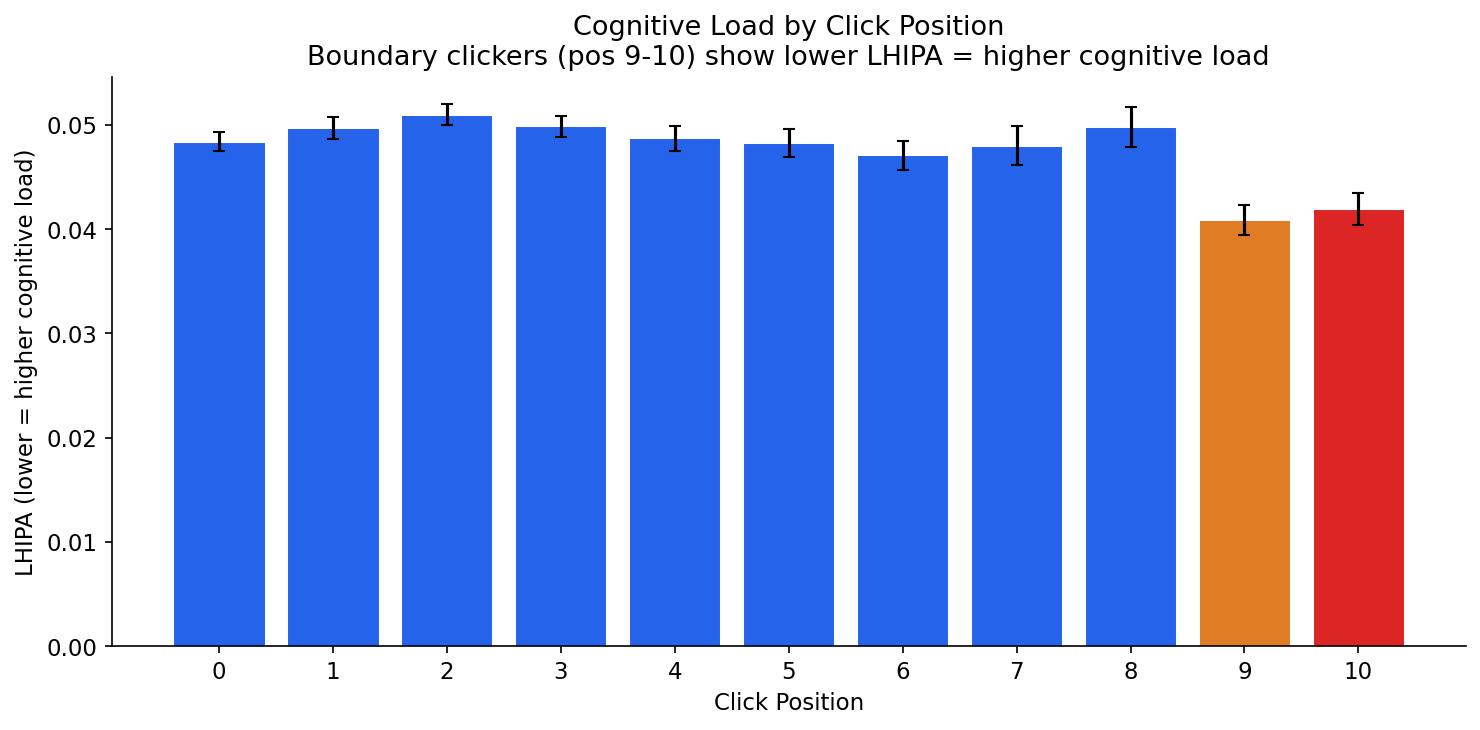

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

colors_l = ['#2563eb'] * max_pos
colors_l[9] = '#e07c24'
colors_l[10] = '#dc2626'

ax.bar(positions, lhipa_means, yerr=lhipa_sems, capsize=3,
       color=colors_l, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Click Position')
ax.set_ylabel('LHIPA (lower = higher cognitive load)')
ax.set_title('Cognitive Load by Click Position\n'
             'Boundary clickers (pos 9-10) show lower LHIPA = higher cognitive load')
ax.set_xticks(positions)

plt.tight_layout()
plt.savefig('plot_skijump_lhipa.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. SERP difficulty modulates the ski-jump

Split by relevance spread (median). Easy SERPs (high spread, one standout result) vs hard SERPs (low spread, all results equidistant from query).

Relevance spread median: 0.0481
Easy SERPs (high spread): N=1385, boundary=13.6%
Hard SERPs (low spread):  N=1386, boundary=10.0%


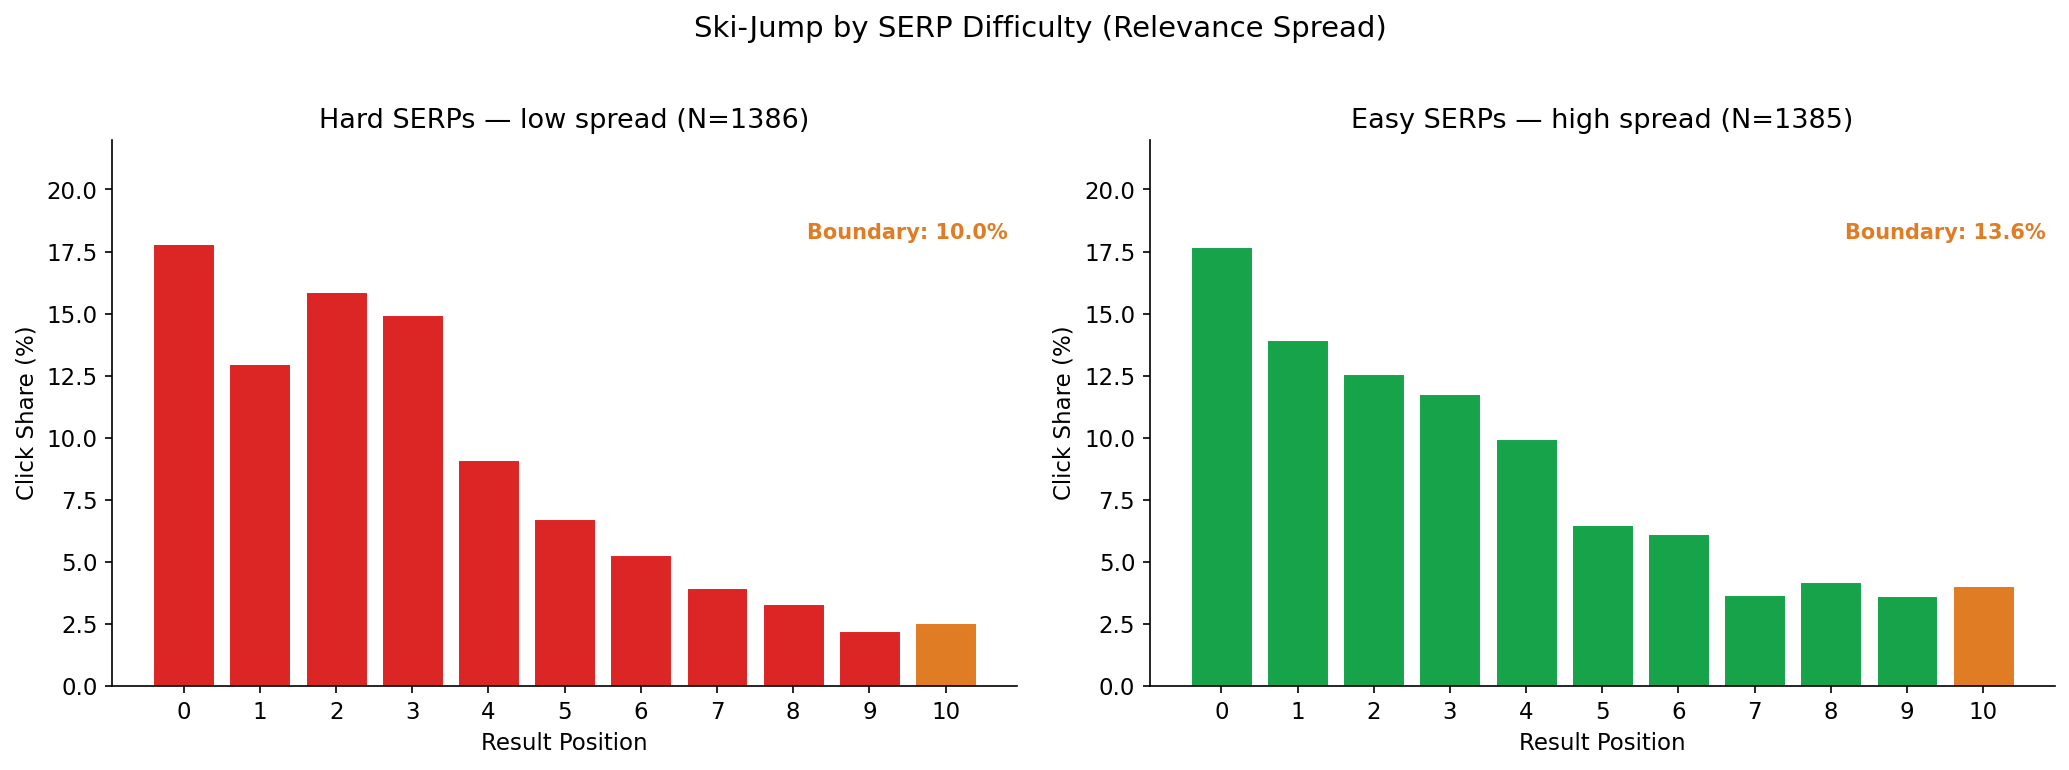

In [8]:
diff = load_difficulty_measures()

spreads = [diff[tid]['relevance_spread'] for tid in diff
           if diff[tid]['relevance_spread'] is not None]
s_med = np.median(spreads)

easy_clicks, hard_clicks = [], []
for d in click_data:
    tid = d['tid']
    if tid in diff and diff[tid]['relevance_spread'] is not None:
        if diff[tid]['relevance_spread'] > s_med:
            easy_clicks.append(d['click_pos'])
        else:
            hard_clicks.append(d['click_pos'])

easy_counts = Counter(easy_clicks)
hard_counts = Counter(hard_clicks)

easy_boundary = sum(1 for c in easy_clicks if c >= 9) / len(easy_clicks) * 100
hard_boundary = sum(1 for c in hard_clicks if c >= 9) / len(hard_clicks) * 100

print(f'Relevance spread median: {s_med:.4f}')
print(f'Easy SERPs (high spread): N={len(easy_clicks)}, boundary={easy_boundary:.1f}%')
print(f'Hard SERPs (low spread):  N={len(hard_clicks)}, boundary={hard_boundary:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, clicks, label, color in [
    (axes[0], hard_clicks, f'Hard SERPs — low spread (N={len(hard_clicks)})', '#dc2626'),
    (axes[1], easy_clicks, f'Easy SERPs — high spread (N={len(easy_clicks)})', '#16a34a'),
]:
    cnts = Counter(clicks)
    sh = [cnts.get(p, 0) / len(clicks) * 100 for p in positions]
    cols = [color] * max_pos
    if sh[10] > sh[9]: cols[10] = '#e07c24'
    ax.bar(positions, sh, color=cols, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Result Position')
    ax.set_ylabel('Click Share (%)')
    ax.set_title(label)
    ax.set_xticks(positions)
    ax.set_ylim(0, 22)
    bnd = sum(1 for c in clicks if c >= 9) / len(clicks) * 100
    ax.annotate(f'Boundary: {bnd:.1f}%', (9.5, 18), ha='center',
                fontsize=10, fontweight='bold', color='#e07c24')

plt.suptitle('Ski-Jump by SERP Difficulty (Relevance Spread)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_skijump_difficulty.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Fixation investment by click position

How does total fixation count and trial duration vary with where the user ultimately clicks? Boundary clickers should show the most fixations (they evaluated the whole SERP).

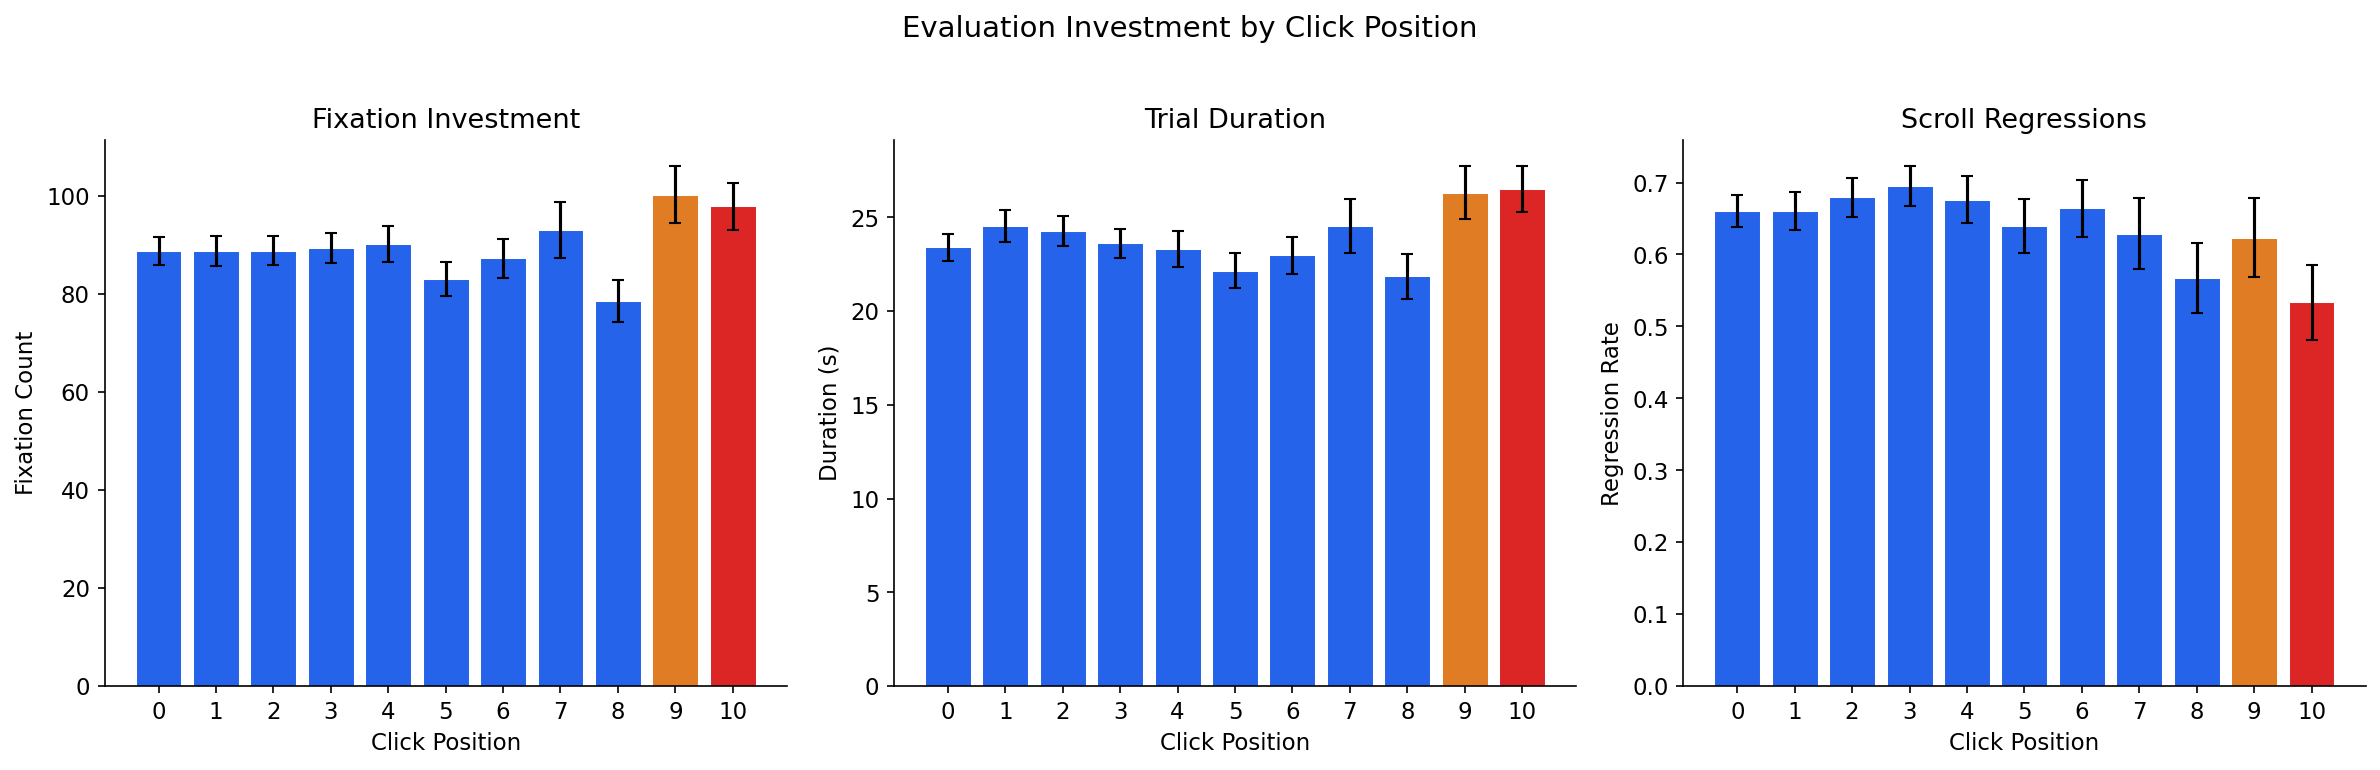

 Pos     Fix   Dur(s)    Reg%      N
-----------------------------------
   0      89     23.4   66.0%    430
   1      89     24.5   66.0%    312
   2      89     24.3   67.9%    287
   3      89     23.6   69.6%    276
   4      90     23.3   67.6%    210
   5      83     22.2   64.0%    161
   6      87     23.0   66.4%    140
   7      93     24.5   62.9%     97
   8      79     21.9   56.7%    104
   9     100     26.3   62.3%     77
  10      98     26.5   53.3%     90


In [9]:
catalog = load_catalog_indexed()

investment_by_pos = defaultdict(lambda: {'fix': [], 'dur': [], 'reg': []})
for d in click_data:
    tid = d['tid']
    if tid in catalog:
        m = catalog[tid]
        investment_by_pos[d['click_pos']]['fix'].append(m['fixation_count'])
        investment_by_pos[d['click_pos']]['dur'].append(m['duration_s'])
        investment_by_pos[d['click_pos']]['reg'].append(m['has_scroll_regression'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, ylabel, title in [
    (axes[0], 'fix', 'Fixation Count', 'Fixation Investment'),
    (axes[1], 'dur', 'Duration (s)', 'Trial Duration'),
    (axes[2], 'reg', 'Regression Rate', 'Scroll Regressions'),
]:
    means = [np.mean(investment_by_pos[p][metric]) if investment_by_pos[p][metric] else 0
             for p in positions]
    sems = [np.std(investment_by_pos[p][metric]) / max(len(investment_by_pos[p][metric]), 1)**0.5
            if investment_by_pos[p][metric] else 0 for p in positions]
    
    cols = ['#2563eb'] * max_pos
    cols[9] = '#e07c24'
    cols[10] = '#dc2626'
    
    ax.bar(positions, means, yerr=sems, capsize=3,
           color=cols, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Click Position')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(positions)

plt.suptitle('Evaluation Investment by Click Position', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_skijump_investment.png', dpi=200, bbox_inches='tight')
plt.show()

# Print the table
print(f'{"Pos":>4s}  {"Fix":>6s}  {"Dur(s)":>7s}  {"Reg%":>6s}  {"N":>5s}')
print('-' * 35)
for p in positions:
    inv = investment_by_pos[p]
    if inv['fix']:
        print(f'{p:4d}  {np.mean(inv["fix"]):6.0f}  {np.mean(inv["dur"]):7.1f}  '
              f'{np.mean(inv["reg"])*100:5.1f}%  {len(inv["fix"]):5d}')


## 6. Summary

### The ski-jump decomposes into:

1. **Monotonic decline** (positions 0–8): attention allocation decision. Fixation count drops, not fixation duration. Users invest fewer looks in lower-ranked results.

2. **Boundary uptick** (position 10 > 9): driven by optimizers who evaluated the whole SERP. They reach the boundary having invested more fixations, more time, and more regressions than early clickers.

3. **Cognitive load at the boundary**: LHIPA drops at positions 9–10, indicating higher cognitive load. Boundary clickers are making a harder decision — they've seen everything and still need to pick.

4. **Difficulty modulation**: Easy SERPs (high relevance spread) produce more boundary clicks — users who scroll all the way down on an easy SERP are likelier to click at the boundary because the standout was lower in the ranking.

In production search, the boundary is "next page" — and the same dynamics should apply, with query reformulation and abandonment as additional exit paths that the forced-choice task eliminates.